# JSBSim C172 Trim and Level-Flight Validation v39

Purpose: isolate whether JSBSim can produce a usable trim/settled initial condition before running PINN-MPC. This notebook does not load the PINN model and does not run MPC. It compares direct JSBSim `do_trim()` attempts against a deterministic settle-trim fallback, then holds the resulting elevator/throttle commands in level flight.

## 0. Install & Imports

In [1]:
!pip install jsbsim -q
print('Install complete')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.9 MB/s eta 0:00:00a 0:00:01
Install complete


In [2]:
import os, json, time, math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import jsbsim
except ImportError as exc:
    raise RuntimeError('JSBSim import failed. Run the install cell first.') from exc

try:
    from google.colab import drive
    drive.mount('/content/drive')
    COLAB_DRIVE_MOUNTED = True
except Exception as exc:
    print('Drive mount skipped or unavailable:', exc)
    COLAB_DRIVE_MOUNTED = False

FPS_PER_KT = 1.687809857
FT_PER_M = 3.280839895


Mounted at /content/drive


## 1. Configuration

In [3]:
EXPERIMENT_NAME = 'jsbsim_c172_trim_level_flight_validation_v39'
RUN_MODE = 'trim_validation'

DT = 0.02
INIT_ALT_FT = 3000.0
INIT_SPEED_KTS = 100.0
INIT_PITCH_DEG = 0.0
INIT_THROTTLE = 0.85
INIT_ELEVATOR = 0.0

# Direct JSBSim trim modes to try. Exact meanings are JSBSim API dependent,
# so we test several integer modes and judge success by the resulting hold flight.
JSBSIM_TRIM_MODES = [0, 1, 2, 3, 4]

# Fallback: deterministic pre-roll that damps pitch and holds speed, then freezes
# the final elevator/throttle as the approximate trim command.
SETTLE_SECONDS = 10.0
SETTLE_TARGET_PITCH_DEG = 0.0
SETTLE_ELEVATOR_LIMIT = 0.25
SETTLE_THROTTLE_LIMIT = 0.12
SETTLE_K_THETA = 0.030
SETTLE_K_Q = 0.018
SETTLE_K_SPEED = 0.0040

HOLD_SECONDS = 60.0
LEVEL_ALT_DRIFT_LIMIT_FT = 50.0
LEVEL_SPEED_DRIFT_LIMIT_KT = 5.0
LEVEL_TAIL_VS_LIMIT_FPS = 1.0
LEVEL_TAIL_Q_RMS_LIMIT_DEG_S = 0.5
TAIL_SECONDS = 10.0

RESULT_ROOT = '/content/drive/MyDrive/Colab Result' if COLAB_DRIVE_MOUNTED else './Colab Result'
SAVE_DIR = os.path.join(RESULT_ROOT, 'PINN_MPC', EXPERIMENT_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)
print('SAVE_DIR:', SAVE_DIR)
print('Scenario:', dict(alt_ft=INIT_ALT_FT, speed_kts=INIT_SPEED_KTS, throttle=INIT_THROTTLE, hold_s=HOLD_SECONDS))


SAVE_DIR: /content/drive/MyDrive/Colab Result/PINN_MPC/jsbsim_c172_trim_level_flight_validation_v39
Scenario: {'alt_ft': 3000.0, 'speed_kts': 100.0, 'throttle': 0.85, 'hold_s': 60.0}


## 2. JSBSim Helpers

In [4]:
def get_prop(fdm, name, default=0.0):
    try:
        return float(fdm[name])
    except Exception:
        return float(default)


def make_fdm(init_alt=INIT_ALT_FT, init_speed_kts=INIT_SPEED_KTS, init_pitch_deg=INIT_PITCH_DEG):
    fdm = jsbsim.FGFDMExec(None, None)
    fdm.set_debug_level(0)
    fdm.load_model('c172p')
    fdm['ic/h-sl-ft'] = float(init_alt)
    fdm['ic/vt-kts'] = float(init_speed_kts)
    fdm['ic/theta-deg'] = float(init_pitch_deg)
    fdm['ic/psi-true-deg'] = 0.0
    fdm.run_ic()
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = float(INIT_THROTTLE)
    fdm['fcs/elevator-cmd-norm'] = float(INIT_ELEVATOR)
    return fdm


def read_state(fdm):
    return {
        'alt_ft': get_prop(fdm, 'position/h-sl-ft'),
        'speed_fps': get_prop(fdm, 'velocities/vt-fps'),
        'speed_kts': get_prop(fdm, 'velocities/vt-fps') / FPS_PER_KT,
        'theta_deg': np.degrees(get_prop(fdm, 'attitude/theta-rad')),
        'q_deg_s': np.degrees(get_prop(fdm, 'velocities/q-rad_sec')),
        'alpha_deg': np.degrees(get_prop(fdm, 'aero/alpha-rad', 0.0)),
        'elevator': get_prop(fdm, 'fcs/elevator-cmd-norm'),
        'throttle': get_prop(fdm, 'fcs/throttle-cmd-norm', INIT_THROTTLE),
    }


def apply_controls_and_step(fdm, elevator, throttle):
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/elevator-cmd-norm'] = float(np.clip(elevator, -1.0, 1.0))
    fdm['fcs/throttle-cmd-norm'] = float(np.clip(throttle, 0.0, 1.0))
    fdm.run()


def hold_fixed_controls(fdm, elevator, throttle, seconds=HOLD_SECONDS, label='hold'):
    steps = max(1, int(float(seconds) / DT))
    rows = []
    for k in range(steps):
        s = read_state(fdm)
        s['time_s'] = k * DT
        s['label'] = label
        s['cmd_elevator'] = float(elevator)
        s['cmd_throttle'] = float(throttle)
        rows.append(s)
        apply_controls_and_step(fdm, elevator, throttle)
    return pd.DataFrame(rows)


def summarize_level_hold(df, label, trim_method, trim_status):
    if df.empty:
        return {'Case': label, 'Trim Method': trim_method, 'Trim Status': trim_status, 'Completed': False}
    tail_n = max(1, int(TAIL_SECONDS / DT))
    tail = df.tail(tail_n)
    alt_drift = float(df['alt_ft'].iloc[-1] - df['alt_ft'].iloc[0])
    speed_drift = float(df['speed_kts'].iloc[-1] - df['speed_kts'].iloc[0])
    tail_vs = float((tail['alt_ft'].iloc[-1] - tail['alt_ft'].iloc[0]) / max(tail['time_s'].iloc[-1] - tail['time_s'].iloc[0], DT))
    tail_q_rms = float(np.sqrt(np.mean(tail['q_deg_s'].values ** 2)))
    pass_level = (
        abs(alt_drift) <= LEVEL_ALT_DRIFT_LIMIT_FT and
        abs(speed_drift) <= LEVEL_SPEED_DRIFT_LIMIT_KT and
        abs(tail_vs) <= LEVEL_TAIL_VS_LIMIT_FPS and
        tail_q_rms <= LEVEL_TAIL_Q_RMS_LIMIT_DEG_S
    )
    return {
        'Case': label,
        'Trim Method': trim_method,
        'Trim Status': str(trim_status),
        'Completed': True,
        'Pass Level Hold': bool(pass_level),
        'Initial Alt (ft)': round(float(df['alt_ft'].iloc[0]), 2),
        'Final Alt (ft)': round(float(df['alt_ft'].iloc[-1]), 2),
        'Alt Drift (ft)': round(alt_drift, 2),
        'Initial Speed (kt)': round(float(df['speed_kts'].iloc[0]), 2),
        'Final Speed (kt)': round(float(df['speed_kts'].iloc[-1]), 2),
        'Speed Drift (kt)': round(speed_drift, 2),
        'Initial Pitch (deg)': round(float(df['theta_deg'].iloc[0]), 3),
        'Mean Pitch (deg)': round(float(df['theta_deg'].mean()), 3),
        'Final Pitch (deg)': round(float(df['theta_deg'].iloc[-1]), 3),
        'Tail VS (ft/s)': round(tail_vs, 3),
        'Tail q RMS (deg/s)': round(tail_q_rms, 3),
        'Max Alpha Abs (deg)': round(float(np.max(np.abs(df['alpha_deg']))), 3),
        'Hold Elevator': round(float(df['cmd_elevator'].iloc[0]), 5),
        'Hold Throttle': round(float(df['cmd_throttle'].iloc[0]), 5),
    }


## 3. Direct JSBSim Trim Attempts

In [5]:
def run_jsbsim_do_trim_case(mode):
    fdm = make_fdm()
    trim_status = 'not_run'
    try:
        result = fdm.do_trim(int(mode))
        trim_status = f'returned:{result}'
    except Exception as exc:
        trim_status = f'exception:{type(exc).__name__}:{exc}'
    s = read_state(fdm)
    elevator = s['elevator']
    throttle = s['throttle']
    df = hold_fixed_controls(fdm, elevator, throttle, HOLD_SECONDS, label=f'jsbsim_do_trim_{mode}')
    summary = summarize_level_hold(df, f'JSBSim do_trim mode {mode}', 'jsbsim_do_trim', trim_status)
    summary['Trim Mode'] = mode
    summary['Trim Pitch Start (deg)'] = round(float(s['theta_deg']), 3)
    summary['Trim Elevator Readback'] = round(float(elevator), 5)
    summary['Trim Throttle Readback'] = round(float(throttle), 5)
    return df, summary


do_trim_logs = []
do_trim_summaries = []
for mode in JSBSIM_TRIM_MODES:
    print('Trying JSBSim do_trim mode:', mode)
    df, summary = run_jsbsim_do_trim_case(mode)
    do_trim_logs.append(df)
    do_trim_summaries.append(summary)

do_trim_summary = pd.DataFrame(do_trim_summaries)
display(do_trim_summary)


Trying JSBSim do_trim mode: 0


     JSBSim Flight Dynamics Model v1.3.0 Apr  9 2026 10:00:08
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

  Sorry, udot doesn't appear to be trimmable
Trying JSBSim do_trim mode: 1
  Sorry, udot doesn't appear to be trimmable
Trying JSBSim do_trim mode: 2
  Sorry, qdot doesn't appear to be trimmable
Trying JSBSim do_trim mode: 3
setPitchRateInPullup():  32.1896, 1, 168.781
1, 0
setPitchRateInPullup() complete
Setting pitch rate and nlf...
pitch rate done ...
nlf done
  Sorry, udot doesn't appear to be trimmable
Trying JSBSim do_trim mode: 4


,Case,Trim Method,Trim Status,Completed,Pass Level Hold,Initial Alt (ft),Final Alt (ft),Alt Drift (ft),Initial Speed (kt),Final Speed (kt),...,Final Pitch (deg),Tail VS (ft/s),Tail q RMS (deg/s),Max Alpha Abs (deg),Hold Elevator,Hold Throttle,Trim Mode,Trim Pitch Start (deg),Trim Elevator Readback,Trim Throttle Readback
0,JSBSim do_trim mode 0,jsbsim_do_trim,exception:TrimFailureError:Trim Failed,True,False,3000.0,2764.99,-235.01,100.0,82.89,...,6.373,0.952,3.139,3.908,0.0,0.85,0,0.0,0.0,0.85
1,JSBSim do_trim mode 1,jsbsim_do_trim,exception:TrimFailureError:Trim Failed,True,False,3000.0,2764.99,-235.01,100.0,82.89,...,6.373,0.952,3.139,3.908,0.0,0.85,1,0.0,0.0,0.85
2,JSBSim do_trim mode 2,jsbsim_do_trim,exception:TrimFailureError:Trim Failed,True,False,3000.0,2764.99,-235.01,100.0,82.89,...,6.373,0.952,3.139,3.908,0.0,0.85,2,0.0,0.0,0.85
3,JSBSim do_trim mode 3,jsbsim_do_trim,exception:TrimFailureError:Trim Failed,True,False,3000.0,2764.99,-235.01,100.0,82.89,...,6.373,0.952,3.139,3.908,0.0,0.85,3,0.0,0.0,0.85
4,JSBSim do_trim mode 4,jsbsim_do_trim,returned:None,True,False,3000.0,2764.99,-235.01,100.0,82.89,...,6.373,0.952,3.139,3.908,0.0,0.85,4,0.0,0.0,0.85


## 4. Settle-Trim Fallback

In [6]:
def settle_fdm_to_trim_reference(fdm, seconds=SETTLE_SECONDS):
    steps = max(1, int(float(seconds) / DT))
    target_speed_fps = INIT_SPEED_KTS * FPS_PER_KT
    elev_cmd = INIT_ELEVATOR
    throttle_cmd = INIT_THROTTLE
    rows = []
    for k in range(steps):
        s = read_state(fdm)
        s['time_s'] = k * DT
        s['label'] = 'settle_preroll'
        rows.append(s)
        pitch_err = s['theta_deg'] - SETTLE_TARGET_PITCH_DEG
        elev_cmd = float(np.clip(SETTLE_K_THETA * pitch_err + SETTLE_K_Q * s['q_deg_s'],
                                 -SETTLE_ELEVATOR_LIMIT, SETTLE_ELEVATOR_LIMIT))
        throttle_delta = SETTLE_K_SPEED * ((target_speed_fps - s['speed_fps']) / FPS_PER_KT)
        throttle_cmd = float(np.clip(INIT_THROTTLE + throttle_delta,
                                     INIT_THROTTLE - SETTLE_THROTTLE_LIMIT,
                                     INIT_THROTTLE + SETTLE_THROTTLE_LIMIT))
        apply_controls_and_step(fdm, elev_cmd, throttle_cmd)
    return elev_cmd, throttle_cmd, pd.DataFrame(rows)


def run_settle_trim_case():
    fdm = make_fdm()
    elev_cmd, throttle_cmd, settle_df = settle_fdm_to_trim_reference(fdm, SETTLE_SECONDS)
    start_state = read_state(fdm)
    df = hold_fixed_controls(fdm, elev_cmd, throttle_cmd, HOLD_SECONDS, label='settle_trim_hold')
    summary = summarize_level_hold(df, 'Settle-trim hold', 'settle_preroll', f'settle:{SETTLE_SECONDS:.1f}s')
    summary['Trim Mode'] = 'settle'
    summary['Trim Pitch Start (deg)'] = round(float(start_state['theta_deg']), 3)
    summary['Trim Elevator Readback'] = round(float(elev_cmd), 5)
    summary['Trim Throttle Readback'] = round(float(throttle_cmd), 5)
    return settle_df, df, summary

settle_preroll_df, settle_hold_df, settle_summary = run_settle_trim_case()
settle_summary_df = pd.DataFrame([settle_summary])
display(settle_summary_df)


,Case,Trim Method,Trim Status,Completed,Pass Level Hold,Initial Alt (ft),Final Alt (ft),Alt Drift (ft),Initial Speed (kt),Final Speed (kt),...,Final Pitch (deg),Tail VS (ft/s),Tail q RMS (deg/s),Max Alpha Abs (deg),Hold Elevator,Hold Throttle,Trim Mode,Trim Pitch Start (deg),Trim Elevator Readback,Trim Throttle Readback
0,Settle-trim hold,settle_preroll,settle:10.0s,True,False,3022.22,2602.96,-419.26,88.47,89.3,...,-1.327,-2.734,0.901,1.881,0.11649,0.89605,settle,4.048,0.11649,0.89605


## 5. Combined Result and Save

In [7]:
all_hold_logs = do_trim_logs + [settle_hold_df]
all_summary = pd.concat([do_trim_summary, settle_summary_df], ignore_index=True)
all_summary = all_summary.sort_values(['Pass Level Hold', 'Alt Drift (ft)'], ascending=[False, True]).reset_index(drop=True)
print('Trim / level-hold comparison:')
display(all_summary)

summary_path = os.path.join(SAVE_DIR, f'jsbsim_c172_trim_level_summary_v39_{RUN_MODE}.csv')
all_summary.to_csv(summary_path, index=False)
print('Saved summary:', summary_path)

logs_path = os.path.join(SAVE_DIR, f'jsbsim_c172_trim_level_hold_logs_v39_{RUN_MODE}.csv')
pd.concat(all_hold_logs, ignore_index=True).to_csv(logs_path, index=False)
print('Saved logs:', logs_path)


Trim / level-hold comparison:


,Case,Trim Method,Trim Status,Completed,Pass Level Hold,Initial Alt (ft),Final Alt (ft),Alt Drift (ft),Initial Speed (kt),Final Speed (kt),...,Final Pitch (deg),Tail VS (ft/s),Tail q RMS (deg/s),Max Alpha Abs (deg),Hold Elevator,Hold Throttle,Trim Mode,Trim Pitch Start (deg),Trim Elevator Readback,Trim Throttle Readback
0,Settle-trim hold,settle_preroll,settle:10.0s,True,False,3022.22,2602.96,-419.26,88.47,89.30,...,-1.327,-2.734,0.901,1.881,0.11649,0.89605,settle,4.048,0.11649,0.89605
1,JSBSim do_trim mode 0,jsbsim_do_trim,exception:TrimFailureError:Trim Failed,True,False,3000.00,2764.99,-235.01,100.00,82.89,...,6.373,0.952,3.139,3.908,0.00000,0.85000,0,0.000,0.00000,0.85000
2,JSBSim do_trim mode 1,jsbsim_do_trim,exception:TrimFailureError:Trim Failed,True,False,3000.00,2764.99,-235.01,100.00,82.89,...,6.373,0.952,3.139,3.908,0.00000,0.85000,1,0.000,0.00000,0.85000
3,JSBSim do_trim mode 2,jsbsim_do_trim,exception:TrimFailureError:Trim Failed,True,False,3000.00,2764.99,-235.01,100.00,82.89,...,6.373,0.952,3.139,3.908,0.00000,0.85000,2,0.000,0.00000,0.85000
4,JSBSim do_trim mode 3,jsbsim_do_trim,exception:TrimFailureError:Trim Failed,True,False,3000.00,2764.99,-235.01,100.00,82.89,...,6.373,0.952,3.139,3.908,0.00000,0.85000,3,0.000,0.00000,0.85000
5,JSBSim do_trim mode 4,jsbsim_do_trim,returned:None,True,False,3000.00,2764.99,-235.01,100.00,82.89,...,6.373,0.952,3.139,3.908,0.00000,0.85000,4,0.000,0.00000,0.85000


Saved summary: /content/drive/MyDrive/Colab Result/PINN_MPC/jsbsim_c172_trim_level_flight_validation_v39/jsbsim_c172_trim_level_summary_v39_trim_validation.csv
Saved logs: /content/drive/MyDrive/Colab Result/PINN_MPC/jsbsim_c172_trim_level_flight_validation_v39/jsbsim_c172_trim_level_hold_logs_v39_trim_validation.csv


## 6. Plots

Saved plot: /content/drive/MyDrive/Colab Result/PINN_MPC/jsbsim_c172_trim_level_flight_validation_v39/jsbsim_c172_trim_level_hold_plot_v39_trim_validation.png


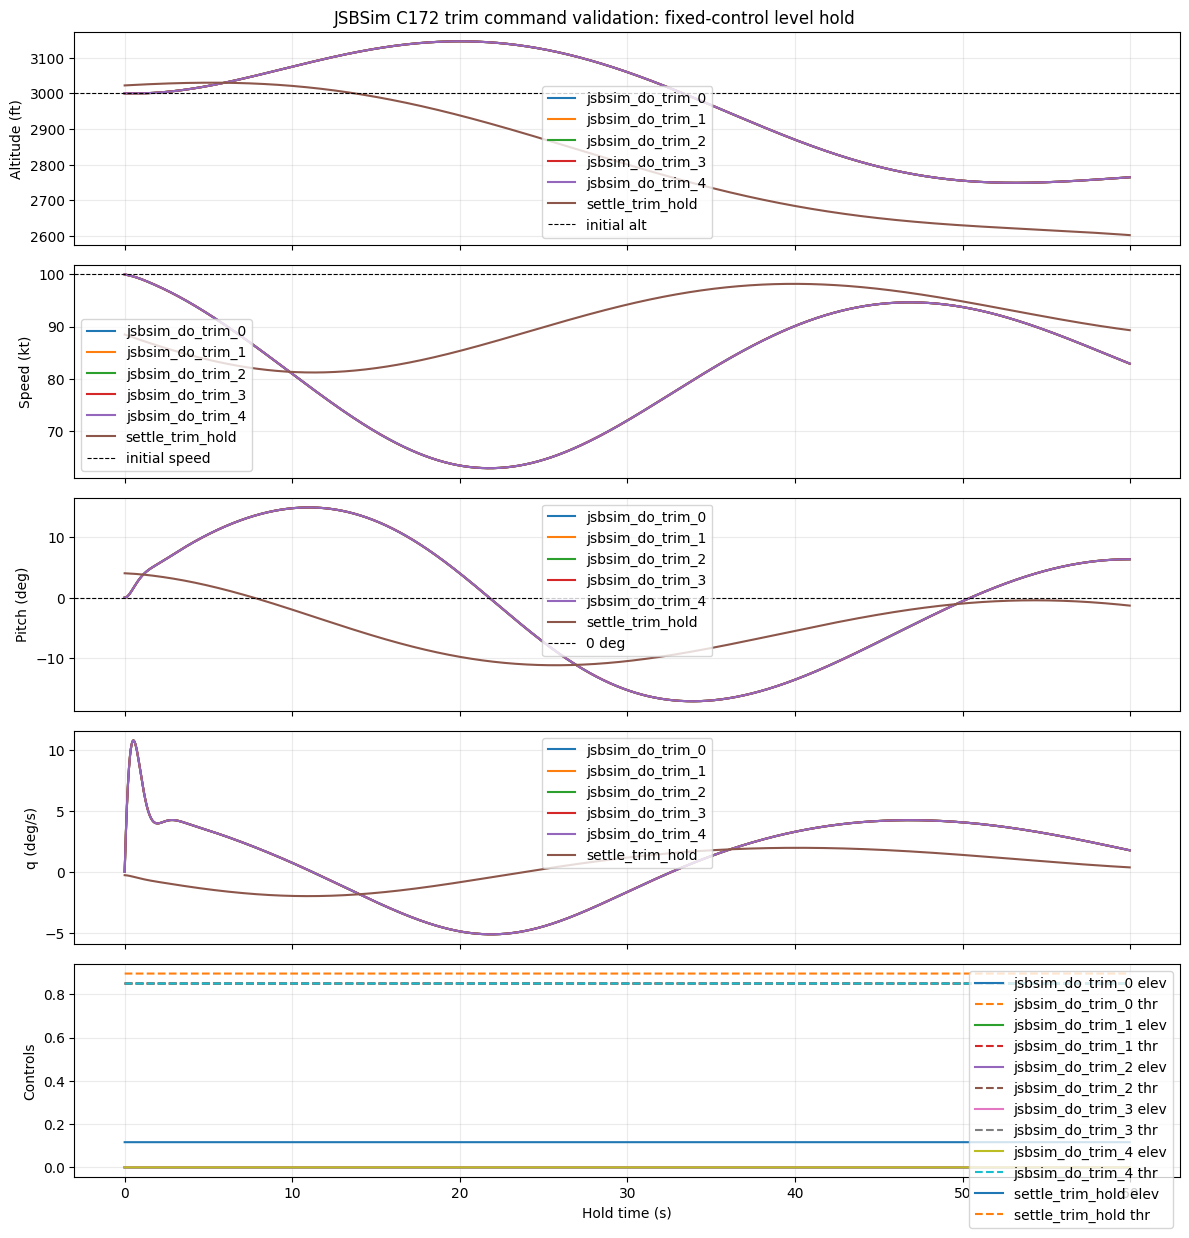

Saved settle plot: /content/drive/MyDrive/Colab Result/PINN_MPC/jsbsim_c172_trim_level_flight_validation_v39/jsbsim_c172_settle_preroll_plot_v39_trim_validation.png


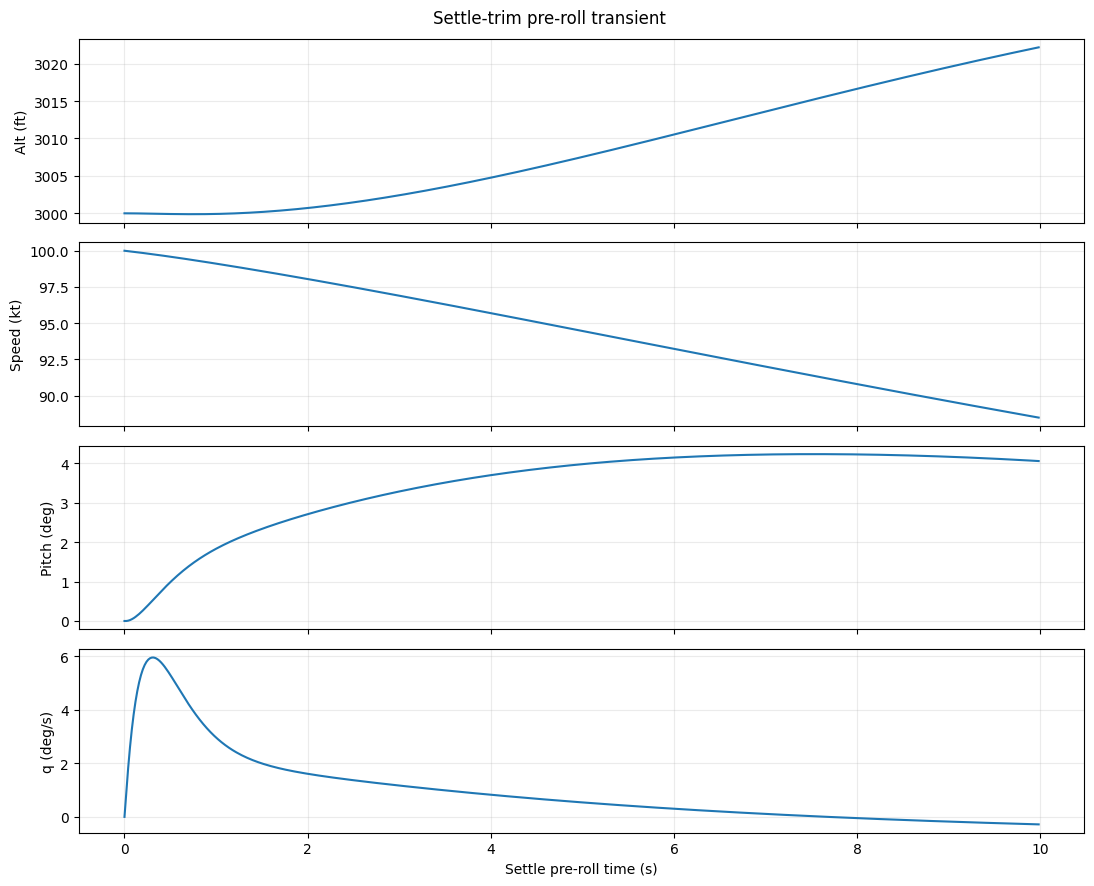

In [8]:
def plot_trim_hold_cases(logs, summary):
    fig, axes = plt.subplots(5, 1, figsize=(12, 13), sharex=True)
    for df in logs:
        if df.empty:
            continue
        label = str(df['label'].iloc[0])
        axes[0].plot(df['time_s'], df['alt_ft'], label=label)
        axes[1].plot(df['time_s'], df['speed_kts'], label=label)
        axes[2].plot(df['time_s'], df['theta_deg'], label=label)
        axes[3].plot(df['time_s'], df['q_deg_s'], label=label)
        axes[4].plot(df['time_s'], df['cmd_elevator'], label=f'{label} elev')
        axes[4].plot(df['time_s'], df['cmd_throttle'], ls='--', label=f'{label} thr')
    axes[0].axhline(INIT_ALT_FT, color='k', ls='--', lw=0.8, label='initial alt')
    axes[1].axhline(INIT_SPEED_KTS, color='k', ls='--', lw=0.8, label='initial speed')
    axes[2].axhline(0.0, color='k', ls='--', lw=0.8, label='0 deg')
    axes[0].set_ylabel('Altitude (ft)')
    axes[1].set_ylabel('Speed (kt)')
    axes[2].set_ylabel('Pitch (deg)')
    axes[3].set_ylabel('q (deg/s)')
    axes[4].set_ylabel('Controls')
    axes[4].set_xlabel('Hold time (s)')
    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(loc='best')
    fig.suptitle('JSBSim C172 trim command validation: fixed-control level hold')
    plt.tight_layout()
    return fig

fig = plot_trim_hold_cases(all_hold_logs, all_summary)
plot_path = os.path.join(SAVE_DIR, f'jsbsim_c172_trim_level_hold_plot_v39_{RUN_MODE}.png')
fig.savefig(plot_path, dpi=160)
print('Saved plot:', plot_path)
plt.show()

# Show settle pre-roll separately.
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(settle_preroll_df['time_s'], settle_preroll_df['alt_ft'])
axes[1].plot(settle_preroll_df['time_s'], settle_preroll_df['speed_kts'])
axes[2].plot(settle_preroll_df['time_s'], settle_preroll_df['theta_deg'])
axes[3].plot(settle_preroll_df['time_s'], settle_preroll_df['q_deg_s'])
axes[0].set_ylabel('Alt (ft)')
axes[1].set_ylabel('Speed (kt)')
axes[2].set_ylabel('Pitch (deg)')
axes[3].set_ylabel('q (deg/s)')
axes[3].set_xlabel('Settle pre-roll time (s)')
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.suptitle('Settle-trim pre-roll transient')
plt.tight_layout()
settle_plot_path = os.path.join(SAVE_DIR, f'jsbsim_c172_settle_preroll_plot_v39_{RUN_MODE}.png')
fig.savefig(settle_plot_path, dpi=160)
print('Saved settle plot:', settle_plot_path)
plt.show()


## 7. Reading Guide

Use `Pass Level Hold` as the first check. A case passes only if the 60 s fixed-control hold stays within altitude drift, speed drift, tail vertical speed, and tail pitch-rate limits. If every direct `do_trim()` case fails but settle-trim passes or is closer, use the settle-trim state as the MPC initial condition. If all cases fail, the requested initial speed/throttle/altitude combination is not a clean level-flight condition for this C172 setup and should be changed before evaluating PID vs PINN-MPC.